# Labelled science phrases & new-term pool — `data.py` demo

This notebook walks through **`data.py`**, the script that standardises the prepared datasets of the *emerging-concepts* study into the `exp_sel_data_out` schema (`{"input", "output", "metadata_*"}` rows grouped per dataset).

The full artifact has seven datasets (D1 OpenAlex stratified corpus, **D2 LLM-labelled candidate phrases**, D3 variant pairs, D4a/b human anchors, D5 survivorship-free phrase pool, D6 held-out phrase works). This demo runs the **D2** builder, `d2_labels()`. It takes candidate noun phrases and acronyms mined from OpenAlex abstracts, which were labelled `CONCEPT` / `NOT_CONCEPT` / `TOO_GENERIC` / `VARIANT_OF` by two LLM labellers, **A = gemini-2.5-flash-lite** and **B = gpt-4.1-nano**, with a **claude-haiku-4.5 adjudicator**. For each phrase it resolves one final *silver* label and assigns a fold (`train` / `test` / `pool_screen`).

`mini_demo_data.json` holds the raw D2 inputs (`labelling/items.json`, `labels_AB.json`, `labels_adj.json`, `split.json`) cut down to **100 diverse keys**: train/test/pool_screen × label family × adjudicated or not. The full D2 set has 4,599 keys.

> Labels are LLM-adjudicated **silver** labels. No human has checked them (`metadata_human_checked = False`).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# pandas, numpy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

## Imports

This is the original import block from `data.py`. The two helper-module imports (`textnorm.schwartz_hearst`, `rawio.read_corpus_works`) live in the artifact's `scripts/` folder. They are only needed by the D1 and D4b builders, which this demo does not run, so they are commented out. `pandas` and `matplotlib` are added for the results section.

In [2]:
from __future__ import annotations

import argparse
import ast
import json
import sys
from pathlib import Path

from loguru import logger

# --- notebook additions (results / visualisation only) ---
import pandas as pd
import matplotlib.pyplot as plt

## Load the demo data

The data comes from GitHub, or from a local `mini_demo_data.json` if the download fails. It contains `items`, `labels_AB`, `labels_adj` and `split`, which mirror the four files that `d2_labels()` reads from `labelling/`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-1/dataset-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["note"])
print({k: (len(v) if isinstance(v, dict) else v) for k, v in data.items() if k != "metadata"})

Raw inputs of data.py::d2_labels() restricted to 100 diverse keys (train/test/pool_screen x label family x adjudicated). Keys mirror labelling/items.json, labels_AB.json, labels_adj.json, split.json.
{'items': 100, 'labels_AB': 2, 'labels_adj': 3, 'split': 2}


## Config

`N_KEYS` is the number of candidate-phrase keys (in sorted order, as `d2_labels()` iterates them) to standardise. The demo file has 100 keys, and the original run used all 4,599 keys of `labelling/items.json`. A value of `None` processes every key present in `data`.

In [5]:
N_KEYS = 100      # original: all keys (4,599 in the full labelling/items.json); demo file holds 100

## Setup: paths and logging

This is the original module-level setup. In the notebook `__file__` does not exist, so `ROOT` is the current directory. That is the only change. `LAB` and `TD` are defined as before but are no longer read from, since the D2 inputs come from `data`.

In [6]:
ROOT = Path(".")                    # original: Path(__file__).resolve().parent
# sys.path.insert(0, str(ROOT / "scripts"))
# from textnorm import schwartz_hearst  # noqa: E402   (only used by d4b_acronyms, not run here)
# from rawio import read_corpus_works  # noqa: E402    (only used by d1_corpus, not run here)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")

LAB = ROOT / "labelling"
TD = ROOT / "temp" / "datasets"

## Shared helpers

- `jl` streams a JSONL file.
- `key_quality` flags known extraction defects in phrase keys: a leading punctuation, symbol or non-Latin character, or publisher boilerplate such as "© Elsevier". Flagged keys are kept and only labelled, so outputs stay reproducible.
- `s` makes sure `input`/`output` are strings, JSON-encoding dicts and lists.

In [7]:
def jl(p: Path):
    with p.open() as f:
        for line in f:
            if line.strip():
                yield json.loads(line)


KEY_OK = __import__("re").compile(r"^[a-z0-9α-ω]")
BOILER = ("©", "wiley periodical", "all rights reserved", "elsevier")


def key_quality(k: str) -> str:
    """Known extraction defect flag (documented in README): keys that start with punctuation/symbols,
    non-Latin script or publisher boilerplate. The normaliser is left unchanged so outputs stay reproducible."""
    if any(b in k for b in BOILER):
        return "boilerplate"
    if not KEY_OK.match(k):
        return "malformed_leading_char"
    return "ok"


def s(x) -> str:
    return x if isinstance(x, str) else json.dumps(x, ensure_ascii=False)

## D2 builder: `d2_labels()`

This is the core of the demo. For each candidate key it:

1. Formats the three labels, A, B and the adjudicator (`VARIANT_OF` becomes `VARIANT_OF:<canonical key>`).
2. **Resolves the final label.** The adjudicator label wins if present. Otherwise the A/B consensus is used. Otherwise the row is `UNRESOLVED`. Every A≠B item in the labelled train/test tracks was adjudicated.
3. **Assigns the fold.** Pool items (track `P`) go to `pool_screen`, and labelled items use the variant-cluster split (`train`/`test`). Unresolved test items are moved to `test_unresolved_excluded`.
4. Builds a stratum string of frequency band | token form | macro-domain, and emits one schema row with the snippets as JSON `input` and the final label as `output`.

The only changes from the original are that the four `json.loads((LAB / ...).read_text())` calls now read from `data`, and the loop is limited to the first `N_KEYS` keys.

In [8]:
def band(n: int) -> str:
    return "3-5" if n <= 5 else "6-20" if n <= 20 else "21-100" if n <= 100 else ">100"


def d2_labels() -> list[dict]:
    items = data["items"]            # original: json.loads((LAB / "items.json").read_text())
    AB = data["labels_AB"]           # original: json.loads((LAB / "labels_AB.json").read_text())
    ADJ = data["labels_adj"]         # original: json.loads((LAB / "labels_adj.json").read_text())
    sp = data["split"]               # original: json.loads((LAB / "split.json").read_text())
    silver = set(ADJ["silver_gold_200"])
    adj = ADJ["labels"]
    out = []
    for k in sorted(items)[:N_KEYS]:  # original: for k in sorted(items):
        it = items[k]
        a, b, j = AB["A"].get(k, {}), AB["B"].get(k, {}), adj.get(k, {})

        def fmt(r: dict) -> str | None:
            if not r.get("label"):
                return None
            return f"VARIANT_OF:{r['variant_of']}" if r["label"] == "VARIANT_OF" and r.get("variant_of") else r["label"]

        la, lb, lj = fmt(a), fmt(b), fmt(j)
        if lj:
            final, basis = lj, "adjudicator"
        elif la and la == lb:
            final, basis = la, "A/B consensus"
        else:
            final, basis = "UNRESOLVED", "A/B disagree, not adjudicated" if la and lb else "missing label"
        if it["track"] == "P":
            fold = "pool_screen"
        else:
            fold = sp["split"][k]
            if fold == "test" and final == "UNRESOLVED":
                fold = "test_unresolved_excluded"
        st = it["stats"]
        form = "acronym" if st["is_acronym_long_form"] else ("1tok" if st["n_tokens"] == 1 else "2tok" if st["n_tokens"] == 2 else "3+tok")
        inp = {"key": k, "surface_forms": it["surface_forms"],
               "acronym_short_forms": it.get("acronym_short_forms", []),
               "snippets": it["snippets"], "n_sample_occ": st["n_occ"],
               "first_sample_year": st["first_main_year"], "n_fields": st["n_fields"]}
        out.append({
            "input": s(inp), "output": final, "metadata_fold": fold,
            "metadata_track": {"L": "L_novel", "L_nonnovel": "L_nonnovel_supplement", "P": "P_pool_screen"}[it["track"]],
            "metadata_label_basis": basis, "metadata_silver_gold_200": k in silver,
            "metadata_label_A": la, "metadata_label_B": lb, "metadata_label_adj": lj,
            "metadata_rationale_A": a.get("rationale"), "metadata_rationale_B": b.get("rationale"),
            "metadata_rationale_adj": j.get("rationale"),
            "metadata_confidence_A": a.get("confidence"), "metadata_confidence_B": b.get("confidence"),
            "metadata_confidence_adj": j.get("confidence"),
            "metadata_model_A": a.get("model"), "metadata_model_B": b.get("model"), "metadata_model_adj": j.get("model"),
            "metadata_label_date": a.get("date") or b.get("date"),
            "metadata_batch_cost_usd_A": a.get("batch_cost"), "metadata_batch_cost_usd_B": b.get("batch_cost"),
            "metadata_variant_cluster": sp["cluster"].get(k),
            "metadata_stratum": f"{band(st['n_occ']) if st['n_occ'] >= 3 else str(st['n_occ'])}|{form}|{st['macro_domain']}",
            "metadata_macro_domain": st["macro_domain"], "metadata_cvalue": st["cvalue"],
            "metadata_in_prescreen_or_pre2005": st["in_pre"], "metadata_audit_arm": bool(it.get("audit_arm", False)),
            "metadata_key_quality": key_quality(k),
            "metadata_human_checked": False,
        })
    return out

## The other dataset builders (reference only, not executed)

The remaining builders from `data.py` are copied unchanged so the notebook matches the full script:

- `d1_corpus`: the OpenAlex stratified corpus with design weights.
- `d3_pairs`: SAME/DIFFERENT variant pairs.
- `d4a_phrases` / `d4b_acronyms`: SemEval-2017/SciERC and acronym-identification human anchors. `d4b` also runs the Schwartz-Hearst acronym extractor.
- `d5_pool`: the survivorship-free phrase pool, early window only.
- `d6_works`: held-out phrase works.
- The extra keyphrase and vocabulary candidates, which are only staged with `--all`.

Their inputs (`raw/`, `data_out/`, `subsample/`, `temp/datasets/`) total several hundred MB and are not part of the demo, so these functions are only **defined** here. Calling them would need the artifact's full workspace.

In [9]:
# ---------------------------------------------------------------- D1
def d1_corpus(limit: int | None = None) -> list[dict]:
    strata = json.loads((ROOT / "raw" / "strata.json").read_text())
    w = {(x["field_id"], x["year"], x["corpus"]): x for x in strata["strata"]}
    out = []
    for i, r in enumerate(read_corpus_works()):
        if limit and i >= limit:
            break
        st = w[(r["stratum_field"], r["stratum_year"], r["corpus"])]
        out.append({
            "input": ((r["title"] or "").strip() + " " + (r["abstract"] or "")).strip(),
            # the corpus is a text source, not a labelled set; output carries the OpenAlex primary field (stratum label)
            "output": r["field"] or "",
            "metadata_fold": f"corpus_{r['corpus']}",
            "metadata_work_id": r["id"], "metadata_doi": r["doi"], "metadata_title": r["title"],
            "metadata_publication_year": r["year"], "metadata_publication_date": r["date"],
            "metadata_field_id": r["field_id"], "metadata_field": r["field"], "metadata_subfield_id": r["subfield_id"],
            "metadata_subfield": r["subfield"], "metadata_domain": r["domain"], "metadata_topic_id": r["topic_id"],
            "metadata_topic": r["topic"], "metadata_venue_id": r["venue_id"], "metadata_venue_type": r["venue_type"],
            "metadata_keywords": r["keywords"], "metadata_legacy_concepts_score_ge_0_3": r["concepts"],
            "metadata_referenced_works_count": r["referenced_works_count"], "metadata_author_ids": r["author_ids"],
            "metadata_institution_ids": r["institution_ids"],
            "metadata_stratum": f"field{r['stratum_field']}_{r['stratum_year']}_{r['corpus']}",
            "metadata_N_stratum": st["N_stratum"], "metadata_n_sampled_stratum": st["n_sampled"],
            "metadata_design_weight": st["design_weight"], "metadata_sample_seed": st["seed"],
        })
    return out


# ---------------------------------------------------------------- D3
def d3_pairs() -> list[dict]:
    V = json.loads((LAB / "variant_pairs.json").read_text())
    out = []
    for p in V["pairs"]:
        out.append({
            "input": s({"phrase_1": p["phrase_1"], "phrase_2": p["phrase_2"], "context_1": p["context_1"], "context_2": p["context_2"]}),
            "output": p["final_label"], "metadata_fold": p["fold"], "metadata_source": p["source"],
            "metadata_gold_source": p["gold_source"], "metadata_label_basis": p["label_basis"],
            "metadata_curated_label": p["curated_label"], "metadata_llm_label_A": p["llm_label_A"],
            "metadata_llm_label_B": p["llm_label_B"], "metadata_llm_label_adj": p["llm_label_adj"],
            "metadata_key_1": p["key_1"], "metadata_key_2": p["key_2"], "metadata_cross_split": p["cross_split"],
            "metadata_cluster_1": p["cluster_1"], "metadata_cluster_2": p["cluster_2"],
        })
    return out


# ---------------------------------------------------------------- D4
def d4a_phrases(limit: int | None = None) -> list[dict]:
    an = json.loads((LAB / "anchor_labels.json").read_text())
    by_phrase = {}
    for k, h in an["items"].items():
        by_phrase[(h["source"], h["source_doc_id"], h["phrase"], h["label"], h.get("entity_type"))] = (an["llm"].get("A", {}).get(k, {}), an["llm"].get("B", {}).get(k, {}))
    out = []
    for i, r in enumerate(jl(ROOT / "raw" / "anchor_phrases.jsonl")):
        if limit and i >= limit:
            break
        la, lb = by_phrase.pop((r["source"], r["source_doc_id"], r["phrase"], r["label"], r.get("entity_type")), ({}, {}))
        out.append({
            "input": s({"phrase": r["phrase"], "sentence_context": r["sentence_context"], "source_doc_id": r["source_doc_id"]}),
            "output": r["label"], "metadata_fold": r["fold"], "metadata_source": r["source"],
            "metadata_entity_type": r.get("entity_type"),
            "metadata_label_origin": "human annotation" if r["label"] != "NOT_ANNOTATED" else "spaCy noun chunk overlapping no human-annotated span",
            "metadata_in_llm_anchor_check": bool(la or lb),
            "metadata_llm_label_A": la.get("label"), "metadata_llm_label_B": lb.get("label"),
        })
    return out


def d4b_acronyms(limit: int | None = None) -> list[dict]:
    out = []
    for i, r in enumerate(jl(ROOT / "raw" / "anchor_acronyms.jsonl")):
        if limit and i >= limit:
            break
        gold = json.loads(r["output"])
        pairs = [{"short_form": a, "long_form": b} for a, b in schwartz_hearst(r["input"])]
        out.append({"input": r["input"], "output": s({"short_forms": gold["short_forms"], "long_forms": gold["long_forms"]}),
                    "metadata_fold": r["fold"], "metadata_sentence_id": r["id"],
                    "metadata_source": "amirveyseh/acronym_identification (SciAD)",
                    "metadata_schwartz_hearst_pred": pairs})
    return out


# ---------------------------------------------------------------- D5
def d5_pool() -> list[dict]:
    pool = json.loads((ROOT / "data_out" / "pool_early.json").read_text())
    out = []
    for p in pool:
        inp = {"key": p["key"], "surface_forms": p["surface_forms"], "acronym_short_forms": p["acronym_short_forms"],
               "snippets": p["snippets"]}
        row = {"input": s(inp), "output": p["link_status"], "metadata_fold": "heldout_phrase"}
        for k, v in p.items():
            if k in ("key", "surface_forms", "acronym_short_forms", "snippets", "link_status"):
                continue
            row[f"metadata_{k}"] = v
        row["metadata_key"] = p["key"]
        row["metadata_key_quality"] = key_quality(p["key"])
        out.append(row)
    return out


# ---------------------------------------------------------------- D6
def d6_works() -> list[dict]:
    return json.loads((ROOT / "subsample" / "heldout_works_rows.json").read_text())


# ---------------------------------------------------------------- extra candidates (staged only)
def midas_keyphrases(repo: str, files: list[tuple[str, str]], limit: int) -> list[dict]:
    out = []
    for fn, fold in files:
        p = TD / repo / fn
        if not p.exists():
            continue
        for r in jl(p):
            doc = r["document"] if isinstance(r["document"], list) else ast.literal_eval(r["document"])
            kp = r.get("extractive_keyphrases")
            kp = kp if isinstance(kp, list) else ast.literal_eval(kp or "[]")
            ab = r.get("abstractive_keyphrases")
            ab = ab if isinstance(ab, list) else ast.literal_eval(ab or "[]")
            out.append({"input": " ".join(doc)[:4000], "output": s({"extractive": kp, "abstractive": ab}),
                        "metadata_fold": fold, "metadata_doc_id": str(r.get("id") or r.get("paper_id") or r.get("document_id") or ""), "metadata_source": repo})
            if len(out) >= limit:
                return out
    return out


def kp20k(limit: int) -> list[dict]:
    out = []
    for r in jl(TD / "taln-ls2n__kp20k" / "test.json"):
        out.append({"input": (r["title"] + ". " + r["abstract"])[:4000], "output": s(r.get("keyphrases")),
                    "metadata_fold": "test", "metadata_doc_id": r["id"], "metadata_prmu": r.get("prmu"),
                    "metadata_source": "taln-ls2n/kp20k"})
        if len(out) >= limit:
            break
    return out


def vocab(kind: str, limit: int) -> list[dict]:
    if kind == "mesh":
        rows = json.loads((TD / "mesh" / "mesh_descriptors_2026.json").read_text())[:limit]
        return [{"input": r["heading"], "output": s(r["entry_terms"]), "metadata_fold": "vocab", "metadata_ui": r["ui"],
                 "metadata_tree_numbers": r["tree_numbers"]} for r in rows]
    rows = json.loads((TD / "openalex_snapshot" / f"{kind}.json").read_text())[:limit]
    return [{"input": r["display_name"] or "", "output": r["id"], "metadata_fold": "vocab",
             **{f"metadata_{k}": v for k, v in r.items() if k not in ("display_name", "id")}} for r in rows]


SELECTED = [
    ("openalex_stratified_corpus_2003_2016_with_prescreen_1995_2004", lambda: d1_corpus()),
    ("llm_labelled_candidate_phrases", d2_labels),
    ("variant_pairs", d3_pairs),
    ("external_human_anchors_semeval2017_scierc_phrases", lambda: d4a_phrases()),
    ("external_human_anchors_acronym_identification", lambda: d4b_acronyms()),
    ("survivorship_free_phrase_pool_early", d5_pool),
    ("heldout_phrase_works", d6_works),
]


def extra_candidates(n: int) -> list[tuple[str, callable]]:
    return [
        ("midas_inspec_keyphrases", lambda: midas_keyphrases("midas__inspec", [("train.jsonl", "train"), ("valid.jsonl", "validation"), ("test.jsonl", "test")], n)),
        ("midas_semeval2010_keyphrases", lambda: midas_keyphrases("midas__semeval2010", [("train.jsonl", "train"), ("test.jsonl", "test")], n)),
        ("midas_nus_keyphrases", lambda: midas_keyphrases("midas__nus", [("test.jsonl", "test")], n)),
        ("taln_ls2n_kp20k_test_keyphrases", lambda: kp20k(n)),
        ("openalex_keywords_vocabulary", lambda: vocab("keywords", n)),
        ("openalex_legacy_concepts_vocabulary", lambda: vocab("concepts", n)),
        ("nlm_mesh_2026_descriptors", lambda: vocab("mesh", n)),
    ]

## Schema check

`check_rows` enforces the `exp_sel_data_out` contract: `input` and `output` must be strings, and every other field must start with `metadata_`.

In [10]:
def check_rows(name: str, rows: list[dict]) -> None:
    bad = 0
    for r in rows:
        if not isinstance(r.get("input"), str) or not isinstance(r.get("output"), str):
            bad += 1
        for k in r:
            if k not in ("input", "output") and not k.startswith("metadata_"):
                raise ValueError(f"{name}: illegal field {k}")
    if bad:
        raise ValueError(f"{name}: {bad} rows with non-string input/output")

## Run: the `main()` loop, restricted to D2

This is the body of the original `main()` (the default mode, without `--all`), with the CLI arguments removed. It loops over `SELECTED`, but only the D2 entry is built, because only D2's inputs are in the demo data. The output is written to `demo_full_data_out.json` instead of `full_data_out.json`.

In [11]:
DEMO_DATASETS = {"llm_labelled_candidate_phrases"}   # notebook addition: only D2 inputs are available

groups = []
for name, fn in SELECTED:
    if name not in DEMO_DATASETS:
        continue
    rows = fn()
    check_rows(name, rows)
    logger.info(f"{name}: {len(rows)} examples")
    groups.append({"dataset": name, "examples": rows})
meta = {
    "artifact": "gen_plan_dataset_4_idx4: labelled concept phrases and survivorship-free phrase pool",
    "created": "2026-09-28",
    "sources": "OpenAlex API (sampled works, counts, works), OpenAlex S3 snapshot (keywords, concepts), NLM MeSH 2026, "
               "Wikidata API, HF: midas/semeval2017, zj88zj/SCIERC, amirveyseh/acronym_identification",
    "label_status": "D2/D3 LLM labels are LLM-adjudicated SILVER labels; no human has checked them (human_checked=false).",
    "sealed_file": "data_out/pool_outcomes_SEALED.json holds the full yearly counts and is deliberately NOT included here.",
}
out_path = ROOT / "demo_full_data_out.json"   # original: --out default ROOT / "full_data_out.json"
out_path.write_text(json.dumps({"metadata": meta, "datasets": groups}, ensure_ascii=False))
logger.info(f"wrote {out_path}")

20:29:52|INFO   |llm_labelled_candidate_phrases: 100 examples


20:29:52|INFO   |wrote demo_full_data_out.json


## Results

The rows produced above are shown as a table. The plots are:

- (left) the final label distribution per fold;
- (middle) how each final label was reached: adjudicator vs. A/B consensus;
- (right) the A-vs-B label confusion matrix, where most disagreements are B over-labelling `CONCEPT`.

Cohen's κ between A and B is printed as well. The artifact reports κ = 0.26 on the full set. With only a handful of keys the value here is noisy.

                                   key        fold       final                         basis           A           B         adj                        stratum key_quality
  activity dependent neural plasticity pool_screen     CONCEPT                 A/B consensus     CONCEPT     CONCEPT        None                 1|3+tok|social          ok
                               armenia        test NOT_CONCEPT                   adjudicator NOT_CONCEPT NOT_CONCEPT NOT_CONCEPT               6-20|1tok|social          ok
                      back translation       train     CONCEPT                   adjudicator NOT_CONCEPT     CONCEPT     CONCEPT                3-5|2tok|social          ok
                                bifeo3        test     CONCEPT                   adjudicator     CONCEPT     CONCEPT     CONCEPT           3-5|acronym|physical          ok
                     boolean operation        test     CONCEPT                   adjudicator     CONCEPT     CONCEPT     CONCEPT 3-5|2tok|co

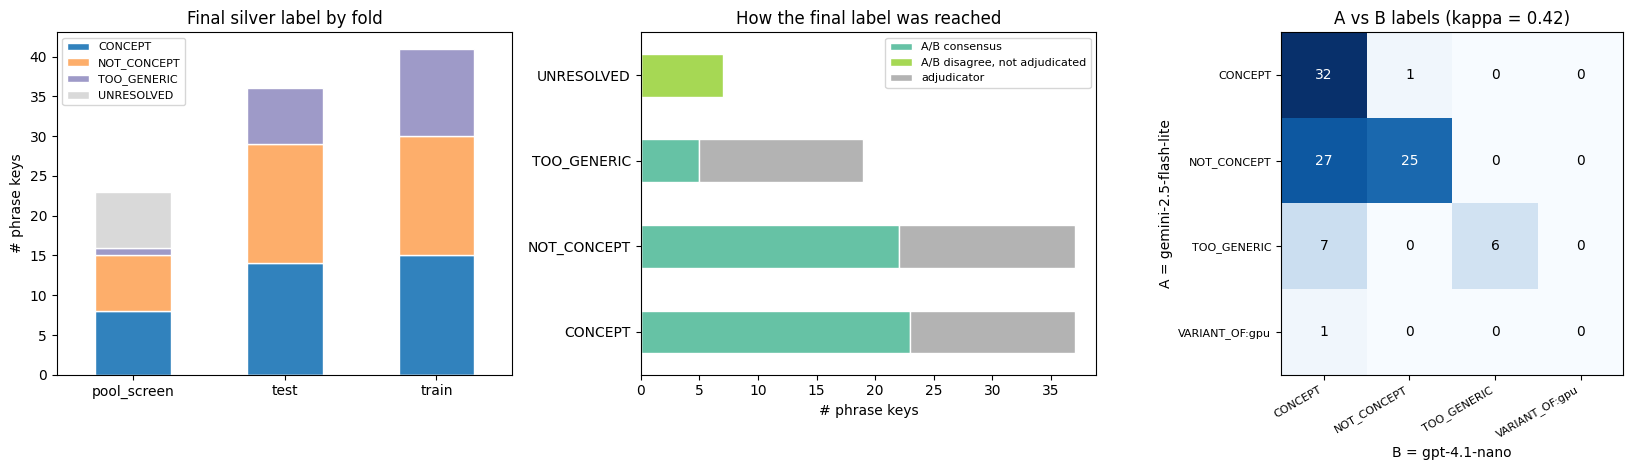

In [12]:
rows = groups[0]["examples"]
df = pd.DataFrame([{
    "key": json.loads(r["input"])["key"], "fold": r["metadata_fold"], "final": r["output"],
    "basis": r["metadata_label_basis"], "A": r["metadata_label_A"], "B": r["metadata_label_B"],
    "adj": r["metadata_label_adj"], "stratum": r["metadata_stratum"], "key_quality": r["metadata_key_quality"],
} for r in rows])
pd.set_option("display.width", 200, "display.max_colwidth", 40)
print(df.head(25).to_string(index=False))
print("\nrows:", len(df))
print("\nfinal label x fold:\n", pd.crosstab(df["final"], df["fold"]))
print("\nlabel basis:\n", df["basis"].value_counts().to_string())
print("\nkey_quality:\n", df["key_quality"].value_counts().to_string())

# Cohen's kappa between labellers A and B (rows where both labelled)
ab = df.dropna(subset=["A", "B"])
labs = sorted(set(ab["A"]) | set(ab["B"]))
po = (ab["A"] == ab["B"]).mean() if len(ab) else float("nan")
pe = sum((ab["A"] == l).mean() * (ab["B"] == l).mean() for l in labs) if len(ab) else float("nan")
kappa = (po - pe) / (1 - pe) if len(ab) and pe < 1 else float("nan")
print(f"\nA-B raw agreement = {po:.2f}, Cohen's kappa = {kappa:.2f}  (n = {len(ab)})")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
ct = pd.crosstab(df["fold"], df["final"])
ct.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20c", edgecolor="white")
axes[0].set_title("Final silver label by fold"); axes[0].set_xlabel(""); axes[0].set_ylabel("# phrase keys")
axes[0].tick_params(axis="x", rotation=0); axes[0].legend(fontsize=8)

bt = pd.crosstab(df["final"], df["basis"])
bt.plot(kind="barh", stacked=True, ax=axes[1], colormap="Set2", edgecolor="white")
axes[1].set_title("How the final label was reached"); axes[1].set_ylabel(""); axes[1].set_xlabel("# phrase keys")
axes[1].legend(fontsize=8)

cm = pd.crosstab(ab["A"], ab["B"]).reindex(index=labs, columns=labs, fill_value=0)
axes[2].imshow(cm.values, cmap="Blues")
axes[2].set_xticks(range(len(labs)), labs, rotation=30, ha="right", fontsize=8)
axes[2].set_yticks(range(len(labs)), labs, fontsize=8)
for i in range(len(labs)):
    for j in range(len(labs)):
        axes[2].text(j, i, cm.values[i, j], ha="center", va="center",
                     color="white" if cm.values[i, j] > cm.values.max() / 2 else "black")
axes[2].set_xlabel("B = gpt-4.1-nano"); axes[2].set_ylabel("A = gemini-2.5-flash-lite")
axes[2].set_title(f"A vs B labels (kappa = {kappa:.2f})")
plt.tight_layout(); plt.show()